Loading local Parquet files...
Engineering temporal deltas...
Mapping outage targets (Eagle1 + DOE 417)...

Starting Randomized Search... (Baseline SPW: 3.30)
Fitting 3 folds for each of 20 candidates, totalling 60 fits

--- OPTIMAL PARAMETERS FOUND ---
subsample: 0.8
scale_pos_weight: 3.2969160104986877
min_child_weight: 5
max_depth: 3
gamma: 0.2
colsample_bytree: 0.8

 TUNED MODEL EVALUATION (TESTING SPLIT)
              precision    recall  f1-score   support

  Normal (0)       1.00      0.84      0.91     15595
  Outage (1)       0.44      0.99      0.61      1944

    accuracy                           0.86     17539
   macro avg       0.72      0.92      0.76     17539
weighted avg       0.94      0.86      0.88     17539

Confusion Matrix:
TN: 13157 | FP: 2438
FN: 24  | TP: 1920

--- DAILY ROLL-UP ---
Outage Days Caught: 80 / 81 (98.8%)

--- TOP 10 DRIVING FEATURES ---
                Feature  Importance
              month_sin    0.319462
              month_cos    0.291716
we

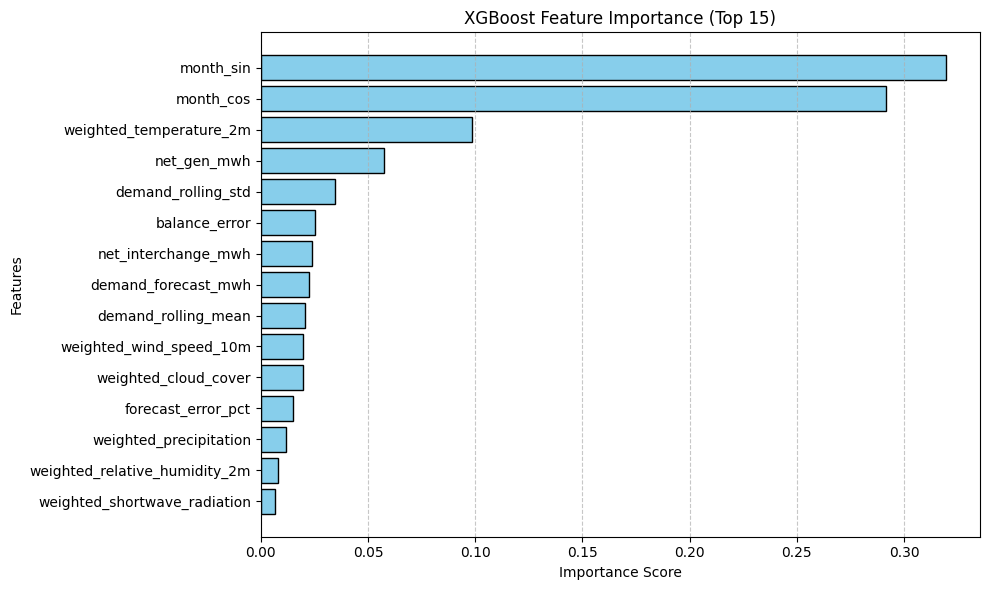

In [21]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix

# ==========================================
# 0. FILE PATHS
# ==========================================
base_path = '/workspaces/CECS-399-499/local_data/gold/'
silver_path = '/workspaces/CECS-399-499/local_data/silver/'

# ==========================================
# 1. DATA INGESTION & MERGING FUNCTIONS
# ==========================================
def extract_and_merge_missing_parquet_data(df_master, csv_path):
    """Extracts global weighted weather from CSV and performs a 1-to-1 merge."""
    temp_grid_load_weather = pd.read_csv(csv_path)
    
    weighted_cols = [
        'timestamp', 'weighted_temperature_2m', 'weighted_relative_humidity_2m', 
        'weighted_precipitation', 'weighted_cloud_cover', 
        'weighted_wind_speed_10m', 'weighted_shortwave_radiation'
    ]
    weighted_df = temp_grid_load_weather[weighted_cols].copy()
    weighted_df['timestamp'] = pd.to_datetime(weighted_df['timestamp'], utc=True).dt.tz_localize(None)
    
    # Strict 1-to-1 merge
    df_master = df_master.merge(weighted_df, on='timestamp', how='inner')
    return df_master


def get_master_data(use_live_db=False):
    """Main data compiler handling live DB vs local parquet routing."""
    if use_live_db:
        print("Connecting to PostgreSQL live database...")
        # Placeholder for your psycopg2 / SQLAlchemy connection logic
        pass

    else:
        print("Loading local Parquet files...")
        
        # Load core TVA-level tables
        energy_feat = pd.read_parquet(f'{base_path}fact_energy_features_hourly.parquet')
        energy_load = pd.read_parquet(f'{base_path}fact_energy_load_hourly.parquet')
        time_dim = pd.read_parquet(f'{base_path}dim_time_hourly.parquet')
        
        # Merge Features + Load
        df = pd.merge(energy_feat, energy_load, on=['time_key', 'source_id'])
        
        # Merge + Time
        df = pd.merge(df, time_dim, left_on='time_key', right_on='time_id', how='left')
        
        # Create Naive Timestamp for Weather Merge
        df['timestamp'] = pd.to_datetime(df['time_key'], utc=True).dt.tz_localize(None)
        
        # Merge Weather
        missing_data_path = f'{silver_path}tn_weighted_weather_21_25.csv'
        df = extract_and_merge_missing_parquet_data(df, missing_data_path)
        
        # Sort entirely chronologically
        df = df.sort_values('timestamp').reset_index(drop=True)
        return df

# ==========================================
# 2. BUILD DATASET & ENGINEER FEATURES
# ==========================================
# Execute the data build
df_master = get_master_data(use_live_db=False)

print("Engineering temporal deltas...")
df_master['demand_delta_1h'] = df_master['actual_demand_mwh'].diff()
df_master['balance_delta_1h'] = df_master['balance_error'].diff()
df_master = df_master.dropna().reset_index(drop=True)

# ==========================================
# 3. CREATE BINARY TARGET (OR Logic)
# ==========================================
print("Mapping outage targets (Eagle1 + DOE 417)...")
# Load Eagle1 Outages
eagle_outages = pd.read_parquet(f'{base_path}fact_outage_daily.parquet')
eagle_dates = set(pd.to_datetime(eagle_outages['date']).dt.date.unique())

# Load DOE 417 Outages
doe_outages = pd.read_csv(f'{silver_path}doe417_tennessee_cleaned_final.csv')
doe_date_col = [c for c in doe_outages.columns if 'date' in c.lower()][0]
doe_dates = set(pd.to_datetime(doe_outages[doe_date_col], format='mixed').dt.date.unique())

# Combine sets and map to master
combined_outage_dates = eagle_dates.union(doe_dates)
df_master['event_date'] = pd.to_datetime(df_master['timestamp']).dt.date
df_master['target'] = df_master['event_date'].apply(lambda x: 1 if x in combined_outage_dates else 0)

# ==========================================
# 4. CHRONOLOGICAL SPLIT
# ==========================================
all_numeric = df_master.select_dtypes(include=[np.number]).columns.tolist()
exclude_from_fit = [
    'time_id', 'time_key', 'source_id', 'year', 'quarter', 
    'month', 'hour_of_day', 'day_of_week', 'target'
]
FEATURES = [f for f in all_numeric if f not in exclude_from_fit]

start_date = df_master['timestamp'].min()
end_date = df_master['timestamp'].max()
split_point = start_date + pd.Timedelta(days=int((end_date - start_date).days * 0.6))

train_df = df_master[df_master['timestamp'] < split_point].copy()
test_df = df_master[df_master['timestamp'] >= split_point].copy()

# ==========================================
# 5. XGBOOST RANDOMIZED SEARCH TUNING
# ==========================================
pos_cases = train_df['target'].sum()
neg_cases = len(train_df) - pos_cases
spw = neg_cases / pos_cases if pos_cases > 0 else 1

param_grid = {
    'scale_pos_weight': [1.0, 1.5, 2.0, 2.5, spw], 
    'max_depth': [3, 4, 5, 6],                     
    'min_child_weight': [1, 3, 5, 7],              
    'subsample': [0.8, 0.9, 1.0],                  
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],      
    'gamma': [0, 0.1, 0.2, 0.3]                    
}

base_clf = xgb.XGBClassifier(
    n_estimators=200,      
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1
)

print(f"\nStarting Randomized Search... (Baseline SPW: {spw:.2f})")
random_search = RandomizedSearchCV(
    estimator=base_clf,
    param_distributions=param_grid,
    n_iter=20,
    scoring='f1',          
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(train_df[FEATURES], train_df['target'])
best_clf = random_search.best_estimator_

print("\n--- OPTIMAL PARAMETERS FOUND ---")
for key, value in random_search.best_params_.items():
    print(f"{key}: {value}")

# ==========================================
# 6. EVALUATION METRICS
# ==========================================
test_df['pred_tuned'] = best_clf.predict(test_df[FEATURES])

print(f"\n{'='*40}")
print(" TUNED MODEL EVALUATION (TESTING SPLIT)")
print(f"{'='*40}")

print(classification_report(test_df['target'], test_df['pred_tuned'], target_names=['Normal (0)', 'Outage (1)']))

cm_tuned = confusion_matrix(test_df['target'], test_df['pred_tuned'])
print("Confusion Matrix:")
print(f"TN: {cm_tuned[0][0]} | FP: {cm_tuned[0][1]}")
print(f"FN: {cm_tuned[1][0]}  | TP: {cm_tuned[1][1]}")

outage_days_tuned = test_df[test_df['target'] == 1]['event_date'].unique()
caught_days_tuned = test_df[(test_df['target'] == 1) & (test_df['pred_tuned'] == 1)]['event_date'].nunique()

print(f"\n--- DAILY ROLL-UP ---")
print(f"Outage Days Caught: {caught_days_tuned} / {len(outage_days_tuned)} ({caught_days_tuned/len(outage_days_tuned) if len(outage_days_tuned) > 0 else 0:.1%})")

# ==========================================
# 7. FEATURE IMPORTANCE OUTPUT
# ==========================================
importances = pd.DataFrame({
    'Feature': FEATURES,
    'Importance': best_clf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n--- TOP 10 DRIVING FEATURES ---")
print(importances.head(10).to_string(index=False))

# Plot and save
plt.rcParams["figure.figsize"] = (10, 6)
plt.barh(importances['Feature'].head(15)[::-1], importances['Importance'].head(15)[::-1], color='skyblue', edgecolor='black')
plt.title('XGBoost Feature Importance (Top 15)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()